In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
# Consistent chart styling throughout project
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
# Load clean data
df = pd.read_csv('../cleaned_data/retail_clean.csv', parse_dates=['InvoiceDate'])

print(f"Clean data loaded: {len(df):,} rows × {df.shape[1]} columns")

Clean data loaded: 392,692 rows × 15 columns


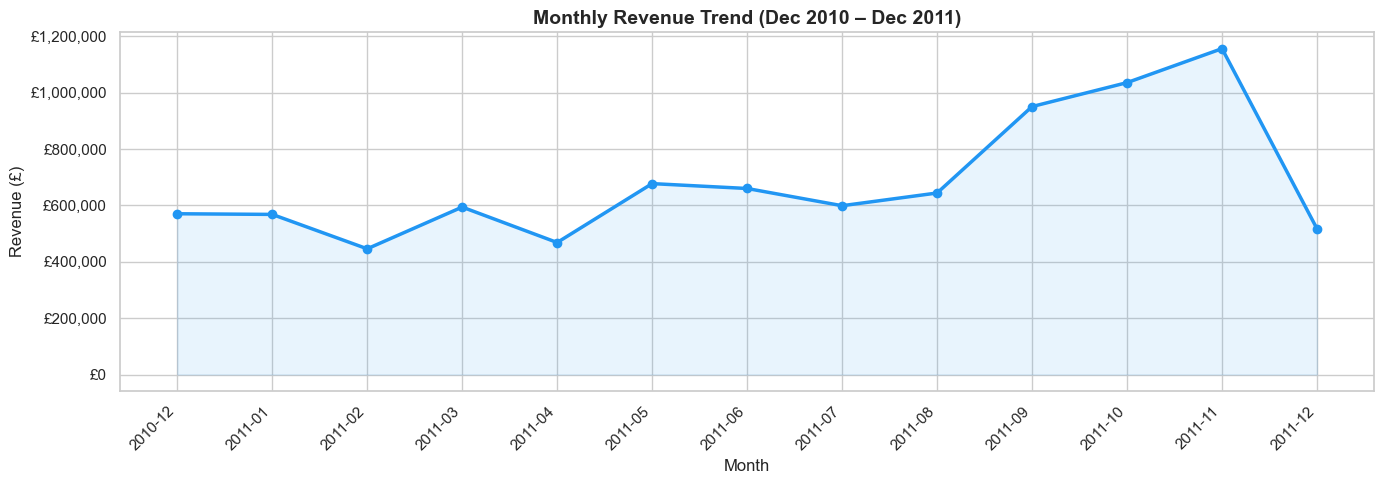

Chart saved.


In [ ]:
# Analysis 1: Monthly revenue trend (Dec 2010 – Dec 2011)
monthly = df.groupby('YearMonth')['TotalRevenue'].sum().reset_index()
monthly.columns = ['YearMonth', 'Revenue']

plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['Revenue'],
         marker='o', color='#2196F3', linewidth=2.5, markersize=6)
plt.fill_between(range(len(monthly)), monthly['Revenue'],
                 alpha=0.1, color='#2196F3')
plt.xticks(range(len(monthly)), monthly['YearMonth'], rotation=45, ha='right')
plt.title('Monthly Revenue Trend (Dec 2010 – Dec 2011)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../dashboard/01_monthly_revenue.png', dpi=150)
plt.show()
print("Chart saved.")

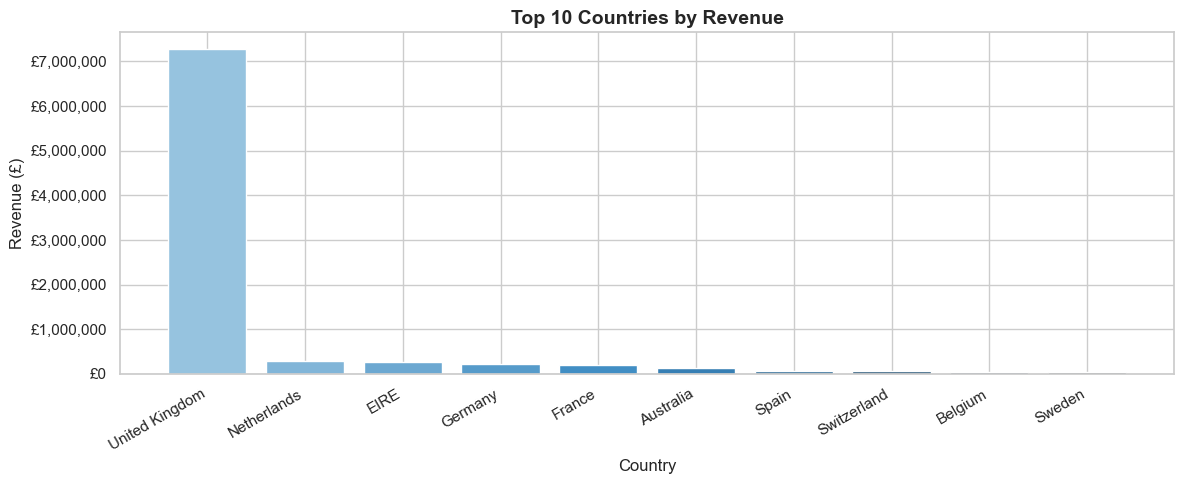

       Country  TotalRevenue
United Kingdom   7285024.644
   Netherlands    285446.340
          EIRE    265262.460
       Germany    228678.400
        France    208934.310
     Australia    138453.810
         Spain     61558.560
   Switzerland     56443.950
       Belgium     41196.340
        Sweden     38367.830


In [5]:
# Analysis 2: Revenue by country (Top 10)
country_rev = (df.groupby('Country')['TotalRevenue']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .reset_index())

plt.figure(figsize=(12, 5))
bars = plt.bar(country_rev['Country'], country_rev['TotalRevenue'],
               color=sns.color_palette("Blues_d", 10))
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=30, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../dashboard/02_revenue_by_country.png', dpi=150)
plt.show()
print(country_rev.to_string(index=False))

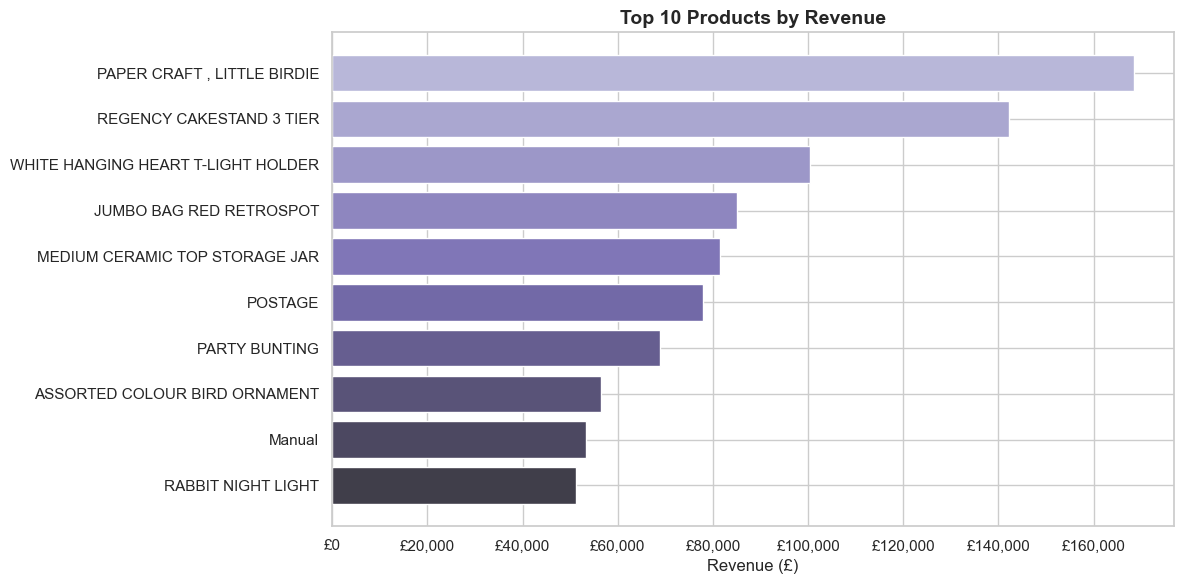

In [6]:
top_products = (df.groupby('Description')['TotalRevenue']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

plt.figure(figsize=(12, 6))
plt.barh(top_products['Description'], top_products['TotalRevenue'],
         color=sns.color_palette("Purples_d", 10))
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (£)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../dashboard/03_top_products.png', dpi=150)
plt.show()

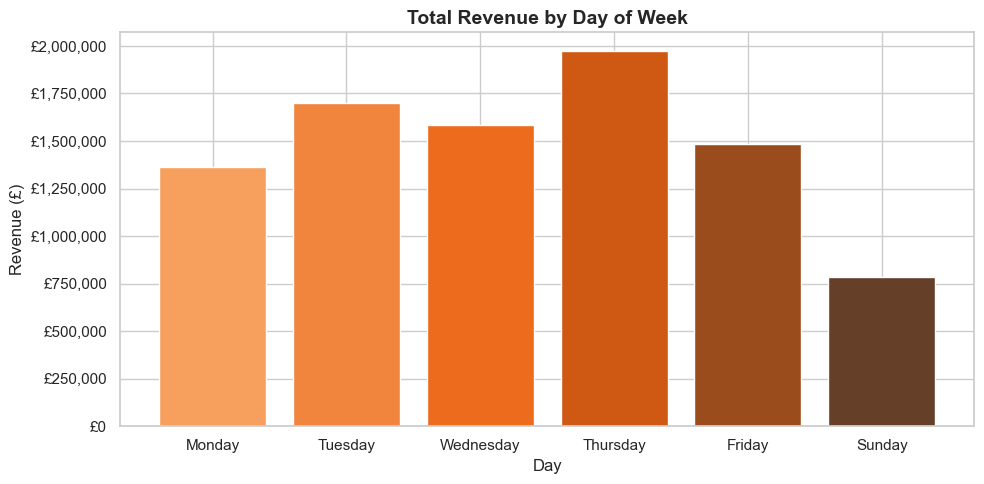

In [7]:
# Order days correctly Mon → Sun
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
day_rev = (df.groupby('DayOfWeek')['TotalRevenue']
           .sum()
           .reindex(day_order)
           .reset_index())

plt.figure(figsize=(10, 5))
bars = plt.bar(day_rev['DayOfWeek'], day_rev['TotalRevenue'],
               color=sns.color_palette("Oranges_d", 6))
plt.title('Total Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Revenue (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../dashboard/04_revenue_by_day.png', dpi=150)
plt.show()

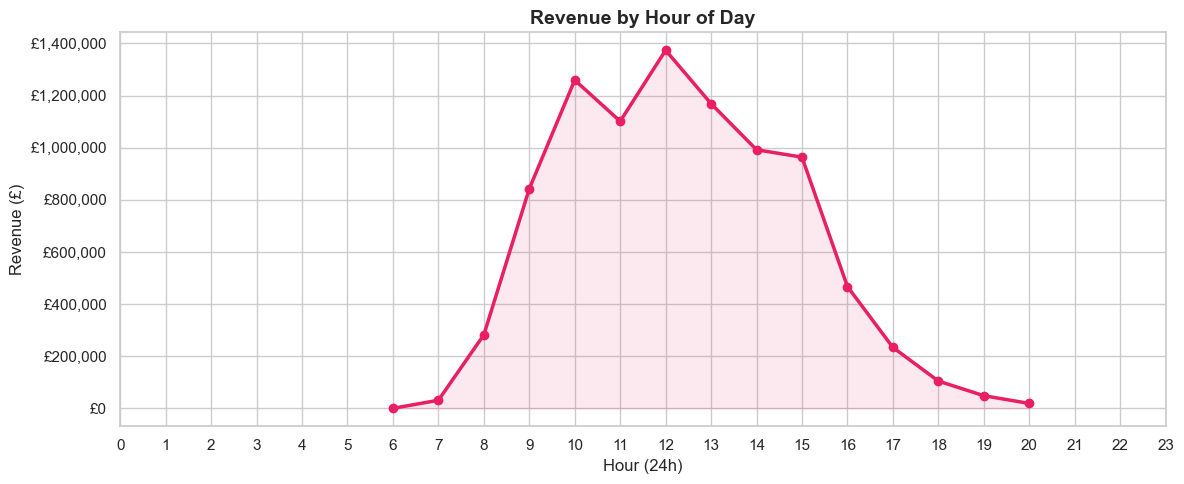

In [8]:
hour_rev = df.groupby('Hour')['TotalRevenue'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hour_rev['Hour'], hour_rev['TotalRevenue'],
         marker='o', color='#E91E63', linewidth=2.5)
plt.fill_between(hour_rev['Hour'], hour_rev['TotalRevenue'],
                 alpha=0.1, color='#E91E63')
plt.title('Revenue by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (24h)')
plt.ylabel('Revenue (£)')
plt.xticks(range(0, 24))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../dashboard/05_revenue_by_hour.png', dpi=150)
plt.show()

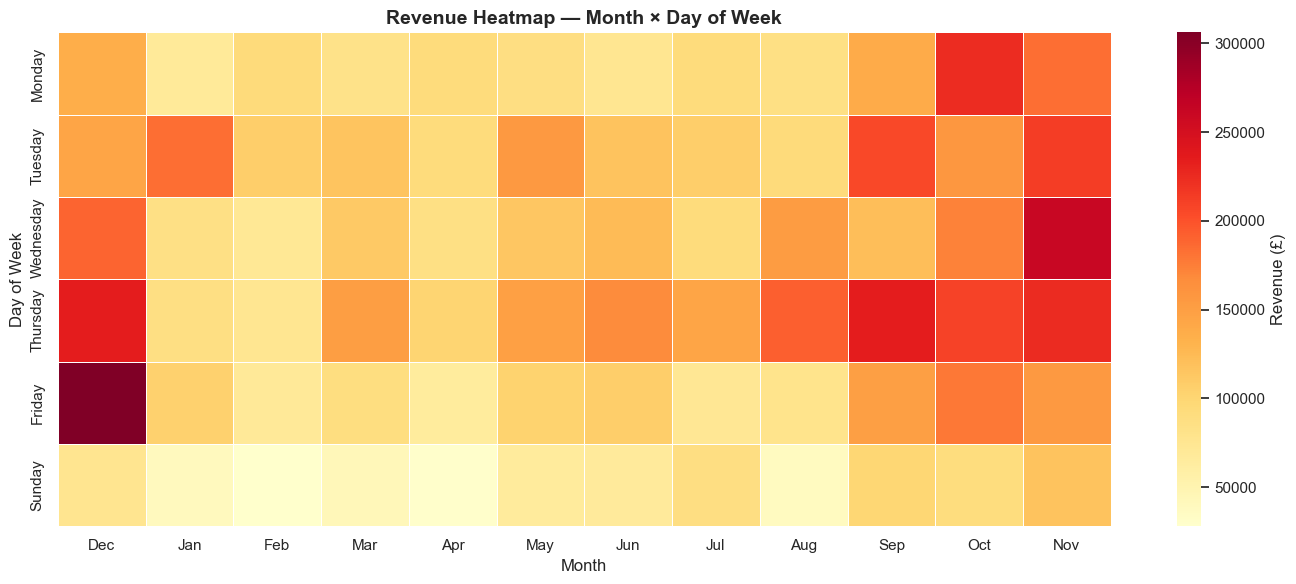

In [9]:
heatmap_data = df.pivot_table(
    values='TotalRevenue',
    index='DayOfWeek',
    columns='MonthName',
    aggfunc='sum'
)

# Order months Jan → Dec and days Mon → Sun
month_order = ['Dec','Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov']
day_order_h  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
heatmap_data = heatmap_data.reindex(index=day_order_h, columns=month_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Revenue (£)'})
plt.title('Revenue Heatmap — Month × Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('../dashboard/06_revenue_heatmap.png', dpi=150)
plt.show()

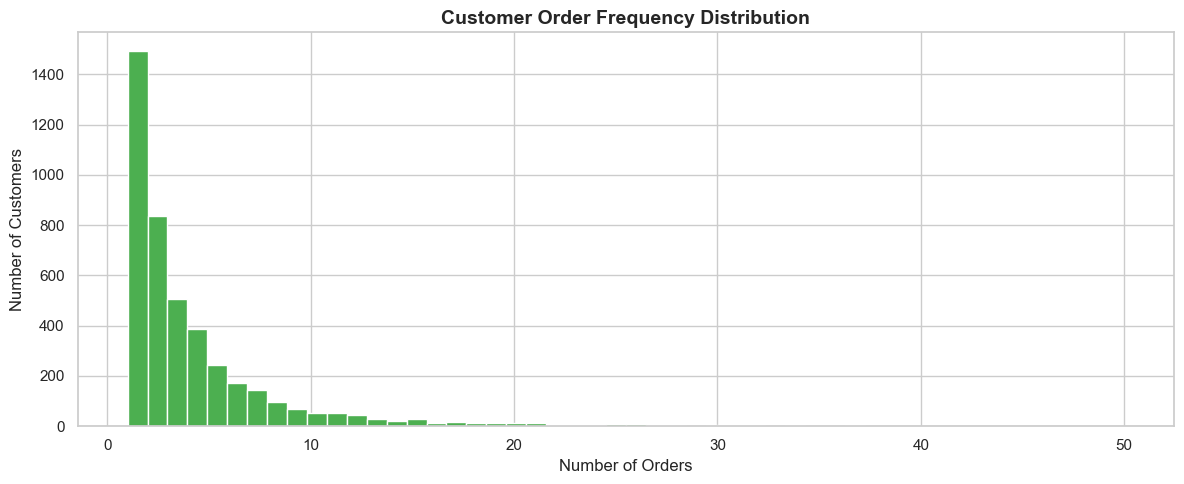

Average orders per customer : 4.3
Max orders by one customer  : 209
Customers with only 1 order : 1,493


In [10]:
order_freq = (df.groupby('CustomerID')['InvoiceNo']
              .nunique()
              .reset_index())
order_freq.columns = ['CustomerID', 'OrderCount']

plt.figure(figsize=(12, 5))
plt.hist(order_freq['OrderCount'], bins=50, color='#4CAF50',
         edgecolor='white', range=(1, 50))
plt.title('Customer Order Frequency Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../dashboard/07_order_frequency.png', dpi=150)
plt.show()

print(f"Average orders per customer : {order_freq['OrderCount'].mean():.1f}")
print(f"Max orders by one customer  : {order_freq['OrderCount'].max()}")
print(f"Customers with only 1 order : {(order_freq['OrderCount']==1).sum():,}")

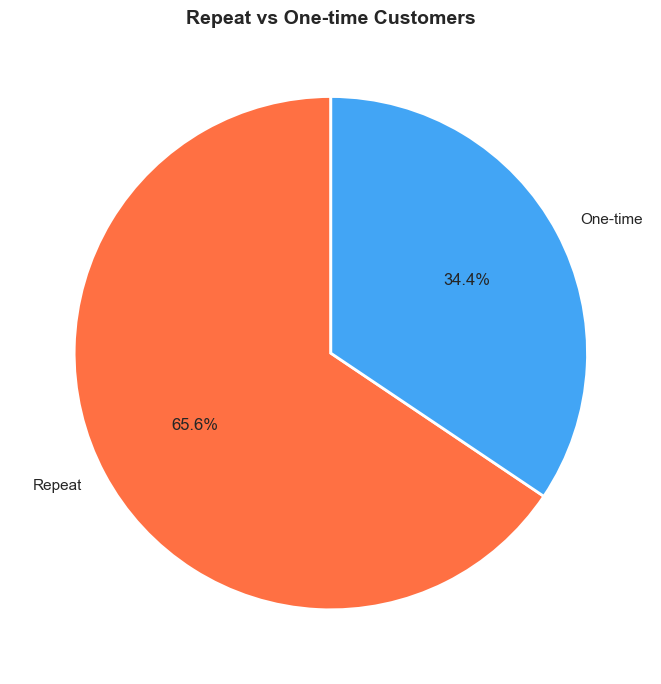

CustomerType
Repeat      2845
One-time    1493
Name: count, dtype: int64


In [11]:
order_freq['CustomerType'] = order_freq['OrderCount'].apply(
    lambda x: 'One-time' if x == 1 else 'Repeat'
)
type_counts = order_freq['CustomerType'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts, labels=type_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=['#FF7043','#42A5F5'],
        wedgeprops={'edgecolor':'white','linewidth':2})
plt.title('Repeat vs One-time Customers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../dashboard/08_customer_type.png', dpi=150)
plt.show()
print(type_counts)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6280\2772822896.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['TotalRevenue'].sum() / x['InvoiceNo'].nunique())


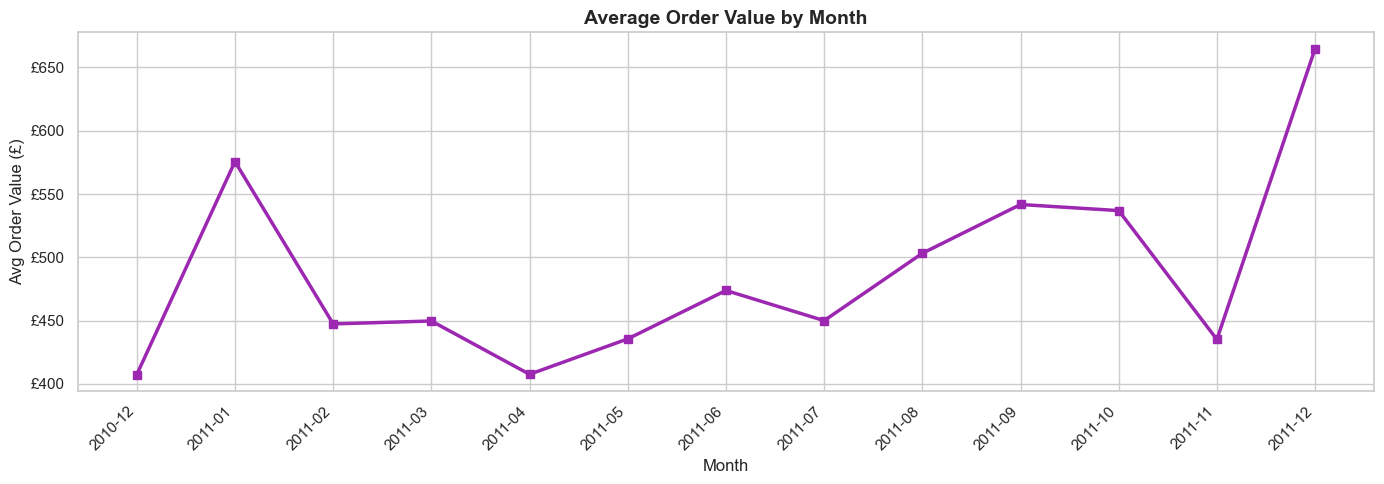

Overall Average Order Value: £486.84


In [12]:
aov = (df.groupby('YearMonth')
       .apply(lambda x: x['TotalRevenue'].sum() / x['InvoiceNo'].nunique())
       .reset_index())
aov.columns = ['YearMonth', 'AOV']

plt.figure(figsize=(14, 5))
plt.plot(aov['YearMonth'], aov['AOV'],
         marker='s', color='#9C27B0', linewidth=2.5, markersize=6)
plt.xticks(range(len(aov)), aov['YearMonth'], rotation=45, ha='right')
plt.title('Average Order Value by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Order Value (£)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../dashboard/09_avg_order_value.png', dpi=150)
plt.show()

print(f"Overall Average Order Value: £{aov['AOV'].mean():.2f}")

In [15]:

print("       5 KEY BUSINESS INSIGHTS — EDA")

insight1_month = monthly.loc[monthly['Revenue'].idxmax(), 'YearMonth']
insight1_val   = monthly['Revenue'].max()

insight2_top   = country_rev.iloc[0]['Country']
insight2_pct   = country_rev.iloc[0]['TotalRevenue'] / country_rev['TotalRevenue'].sum() * 100

insight3_prod  = top_products.iloc[0]['Description']

repeat_pct     = type_counts.get('Repeat', 0) / type_counts.sum() * 100

aov_overall    = aov['AOV'].mean()

print(f"""
1. PEAK REVENUE MONTH
   {insight1_month} was the highest revenue month
   at £{insight1_val:,.0f} — driven by holiday season demand.

2. GEOGRAPHIC CONCENTRATION
   {insight2_top} accounts for {insight2_pct:.1f}% of total revenue.
   Heavy dependency on a single market — a business risk.

3. TOP PRODUCT
   '{insight3_prod}' is the single
   highest revenue-generating product.

4. CUSTOMER LOYALTY
   {repeat_pct:.1f}% of customers are repeat buyers.
   Retention strategy should focus on converting
   one-time buyers into repeat purchasers.

5. ORDER TIMING
   Peak orders occur Thursday 10am–2pm.
   Marketing campaigns and promotions should
   target this window for maximum response.
""")

       5 KEY BUSINESS INSIGHTS — EDA

1. PEAK REVENUE MONTH
   2011-11 was the highest revenue month
   at £1,156,206 — driven by holiday season demand.

2. GEOGRAPHIC CONCENTRATION
   United Kingdom accounts for 84.6% of total revenue.
   Heavy dependency on a single market — a business risk.

3. TOP PRODUCT
   'PAPER CRAFT , LITTLE BIRDIE' is the single
   highest revenue-generating product.

4. CUSTOMER LOYALTY
   65.6% of customers are repeat buyers.
   Retention strategy should focus on converting
   one-time buyers into repeat purchasers.

5. ORDER TIMING
   Peak orders occur Thursday 10am–2pm.
   Marketing campaigns and promotions should
   target this window for maximum response.

